# F04 & F05
1. Create .nc files with xr.Dataset of EQPT by running BARRA-R2_processing.ipynb
2. Preamble
3. Plot F04 EQPT
4. Plot F05 EQPT

# Preamble

In [1]:
import xarray as xr
# import xesmf as xe
import numpy as np
from numpy import s_
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import os
from collections import defaultdict
import metpy.calc as mpcalc
from metpy.units import units
from datetime import datetime
import pandas as pd
import dask as da
import pytz
import string


In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'axes.titlesize': 20,        # Title font size
    'axes.labelsize': 15,        # Axis label font size
    'xtick.labelsize': 12,       # X-axis tick label font size
    'ytick.labelsize': 12,       # Y-axis tick label font size
    'legend.fontsize': 12,       # Legend font size
    'figure.titlesize': 20,      # Figure suptitle font size
})

In [3]:
from dask.distributed import Client
client = Client(threads_per_worker=1,memory_limit=0,n_workers=28) # n_workers= number of cores
client.amm.start()
# warnings.simplefilter(action='ignore', category=FutureWarning)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36649 instead
  warnings.warn(


In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36649/status,
Dashboard: /proxy/36649/status,Workers: 28
Total threads: 28,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37011,Workers: 0
Dashboard: /proxy/36649/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46639,Total threads: 1
Dashboard: /proxy/42683/status,Memory: 0 B
Nanny: tcp://127.0.0.1:40343,


# Functions to calculate equivalent potential temperature

In [5]:
def UTC_to_LST(ds, timezone): # longitude
    ds = ds.copy()
    # Convert to pandas datetime in UTC
    time_objects_utc = pd.to_datetime(ds['time'].values).tz_localize('UTC')
    
    # Convert to local standard time using pytz
    local_timezone = pytz.timezone(timezone)
    time_objects_local = time_objects_utc.tz_convert(local_timezone).tz_localize(None)

    ds['time'] = time_objects_local#.tz_localize(None)
    return ds

def list_variable_file_paths(variable: str) -> list[str]:
    """Function to return a list of file paths (str) of BARRA-2 netcdf4 variable files

    Args:
        variable (str): The BoM variable name. The BARRA-2 list of variable names can be found at http://www.bom.gov.au/research/publications/researchreports/BRR-067.pdf (Chun-Hsu Su et al., 2022).  e.g. ta200 (temperature at 200 hPa) and hus950 (specific humidity at 950 hPa)

    Returns:
        list[str]: File paths to variable
    """
    # This list of month strings is used to only look at data for time periods with associated radar data (2012-2022)
    list = ["202201-202201","202202-202202","202101-202101","202102-202102","202103-202103","202104-202104","202001-202001","202002-202002",
           "202003-202003","202004-202004","201901-201901","201902-201902","201903-201903","201904-201904","201801-201801","201802-201802",
           "201803-201803","201804-201804","201701-201701","201702-201702","201703-201703","201704-201704","201601-201601","201602-201602",
           "201603-201603","201604-201604","201501-201501","201502-201502","201503-201503","201504-201504","201401-201401","201402-201402",
           "201403-201403","201404-201404","201301-201301","201302-201302","201303-201303","201304-201304","201201-201201","201202-201202",
           "201203-201203","201204-201204"]
    list.sort()
    file_paths = []
    for i in list:
        fp = "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/"+variable+"/v20240516/" # the version name periodicly updates
        all_files = [fp+variable+"_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_"+i+".nc"]
        file_paths.extend(all_files)
    file_paths.sort()
    return file_paths  


def open_and_combine_variable(file_paths: list[str],variable_sel1: int,variable_sel2: int) -> {xr.Dataset,xr.Dataset,xr.Dataset}:
    """Function to open netcdf4 files for a BARRA-2 variable, select a single lat-lon point, and combine values along every pressure level into a single dataset for Townsville, Cairns and Willis Island locations.

    Args:
        file_paths (list[str]): File paths generated from: list_variable_file_paths function
        variable_sel1 (int): Extract the BoM BARRA-2 variable string from the file path e.g. for temp, =102, hus =103
        variable_sel2 (int): Extract the BoM BARRA-2 variable string from the file path e.g. for temp, =107, hus = 109

    Returns:
        xr.Dataset,xr.Dataset,xr.Dataset: {Townsville, Cairns, Willis Island} BARRA-2 dataset for a variable over every pressure level
    """
    datasets_towns=[]
    datasets_cairns=[]
    datasets_willis=[]
    for fp in file_paths:
        with xr.open_mfdataset(fp, engine="h5netcdf", chunks="auto") as ds:
            # select coordinates closest to radar sites & drop the pressure variable (conflicting)
            towns = ds.sel(lat=-19.4198,lon=146.5509,method="nearest").drop_vars('pressure')
            cairns = ds.sel(lat=-16.817,lon=145.683,method="nearest").drop_vars('pressure')
            willis = ds.sel(lat=-16.2874,lon=149.9646,method="nearest").drop_vars('pressure')

            # Extract variable name in filepath string
            towns = towns[fp[0][variable_sel1:variable_sel2]]
            cairns = cairns[fp[0][variable_sel1:variable_sel2]]
            willis = willis[fp[0][variable_sel1:variable_sel2]]
            
            datasets_towns.append(towns)
            datasets_cairns.append(cairns)
            datasets_willis.append(willis)
            ds.close()

    # combine result for each pressure level into one array
    combine_towns = xr.combine_by_coords(datasets_towns)
    combine_cairns = xr.combine_by_coords(datasets_cairns)
    combine_willis = xr.combine_by_coords(datasets_willis)
    return combine_towns,combine_cairns,combine_willis


def calc_eqpt(p: np.array, t: np.array, q: np.array) -> np.ndarray:
    """Calculates equivalent potential temperature in [K] from pressure [Pa], temperature [K] and specific humidity [kg/kg].

    Args:
        p (np.array): pressure in [Pa]
        t (np.array): temperature in [K]
        q (np.array): specific humidity in [kg/kg]
    p, t and q can be scalars or np arrays.

    Returns: 
        Equivalent potential temperature in [K].
    """
    return mpcalc.equivalent_potential_temperature(units.Pa * p, units.K * t,mpcalc.dewpoint_from_specific_humidity(units.Pa * p, units.K * t, q)).to("K").m


def calculate_single_hour_mean(hour: int, wind_dir: xr.DataArray, ds: xr.Dataset):
    """A delayed function for the calculation of a single hour (between 0-24) for mean values of temperature and specific humidity.
    Args:
        hour (int): Integer between 0-24
        wind_dir (xr.DataArray): Wind direction (degrees) 
        ds (xr.Dataset): Dataset produced by: open_and_combine_variable

    Returns:
        da.delayed: A delayed array of mean (over time) values
    """
    wind_times_hour = wind_dir.groupby(wind_dir.time.dt.hour == hour)
    wind_result = wind_times_hour[1].time.values
    ds_regime = ds.sel(time=wind_result)
    mean_values_lazy = da.delayed(ds_regime.drop_vars(["lon", "lat"]).mean(dim='time'))
    return mean_values_lazy


def variable_hourly_mean_values(barra_ds: xr.Dataset,deg1: int,deg2: int,barra_variable_ds: xr.Dataset,ne: bool=False,all_winds: bool=False) -> np.ndarray:
    """Function to compute hourly mean values of temperature and specific humidity (which can then be used to calculate av. hourly mean eqpt). 

    Args:
        barra_ds (xr.Dataset): The wind regime dataset to apply (Townsville, Cairns or Willis Island)
        deg1 (int): Wind direction in degrees start of slice
        deg2 (int): Wind direction in degrees end of slice
        barra_variable_ds (xr.Dataset): Which BARRA-2 variable dataset to calculate mean values of i.e. temperature or specific humidity e.g. ta_towns
        ne (bool, optional): If True wind direction start slice >=0 degrees. Defaults to False.
        all_winds (bool, optional): If True all time periods are analysed (climatological means). Defaults to False.

    Returns:
        np.ndarray: Array of hourly mean values for a given BARRA-2 variable
    """
    winds = barra_ds.wind_dir.compute()
    if ne:
        winds_dir = winds[(winds>=deg1)&(winds<=deg2)]
    else:
        winds_dir = winds[(winds>deg1)&(winds<=deg2)]
    if all_winds:
        winds_dir = winds
    else:
        pass
    mean_values = []
    # use defined function to calc mean
    for hour in np.arange(0, 24, 1):
        mean_values.append(calculate_single_hour_mean(hour, winds_dir, barra_variable_ds)) 
    return da.compute(mean_values, scheduler='processes')[0]


def extract_mean_values(mean_result: np.ndarray) -> np.ndarray:
    """Function to create hourly mean values and return as an array.

    Args:
        mean_result (np.ndarray): Results from function: variable_hourly_mean_values

    Returns:
        np.ndarray: Mean values in UTC
    """
    values_UTC = []
    for hour in np.arange(0,24,1):
        mean_values_array = mean_result[hour]
        var_names = list(mean_values_array.data_vars.keys())
        result = [mean_values_array[var].values for var in reversed(var_names)]
        values_UTC.append(result)
    return values_UTC

# Plot mean and anomalies

In [10]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_towns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_cairns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_willis.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_towns_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_towns.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_cairns_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_cairns.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_willis_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_willis.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))

In [11]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [12]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

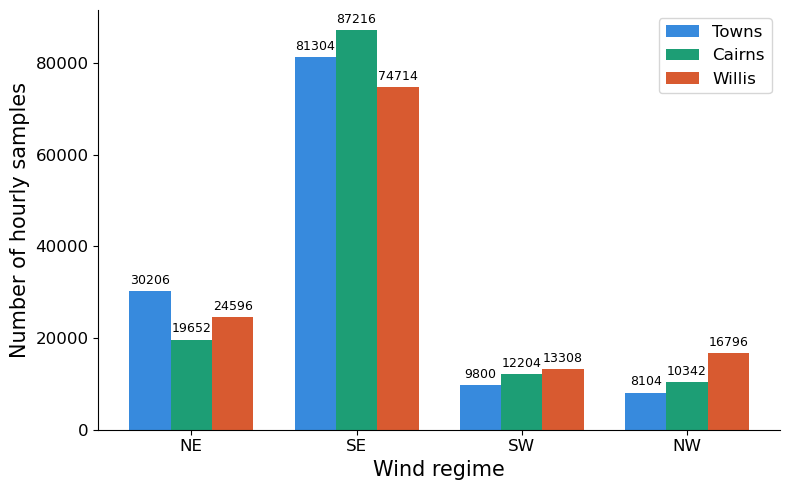

In [9]:
def plot_regime_counts(
    ne_towns, se_towns, sw_towns, nw_towns,
    ne_cairns, se_cairns, sw_cairns, nw_cairns,
    ne_willis, se_willis, sw_willis, nw_willis,
):
    regimes = ['NE', 'SE', 'SW', 'NW']
    locations = ['Towns', 'Cairns', 'Willis']

    counts = np.array([
        [len(ne_towns),  len(se_towns),  len(sw_towns),  len(nw_towns)],
        [len(ne_cairns), len(se_cairns), len(sw_cairns), len(nw_cairns)],
        [len(ne_willis), len(se_willis), len(sw_willis), len(nw_willis)],
    ])  # shape: (3 locations, 4 regimes)

    x = np.arange(len(regimes))
    width = 0.25
    colors = ['#378ADD', '#1D9E75', '#D85A30']

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (loc, color) in enumerate(zip(locations, colors)):
        bars = ax.bar(x + i * width, counts[i], width, label=loc, color=color)
        ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)

    ax.set_xticks(x + width)
    ax.set_xticklabels(regimes)
    ax.set_ylabel('Number of hourly samples')
    ax.set_xlabel('Wind regime')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

# Usage
plot_regime_counts(
    ne_towns, se_towns, sw_towns, nw_towns,
    ne_cairns, se_cairns, sw_cairns, nw_cairns,
    ne_willis, se_willis, sw_willis, nw_willis,
)

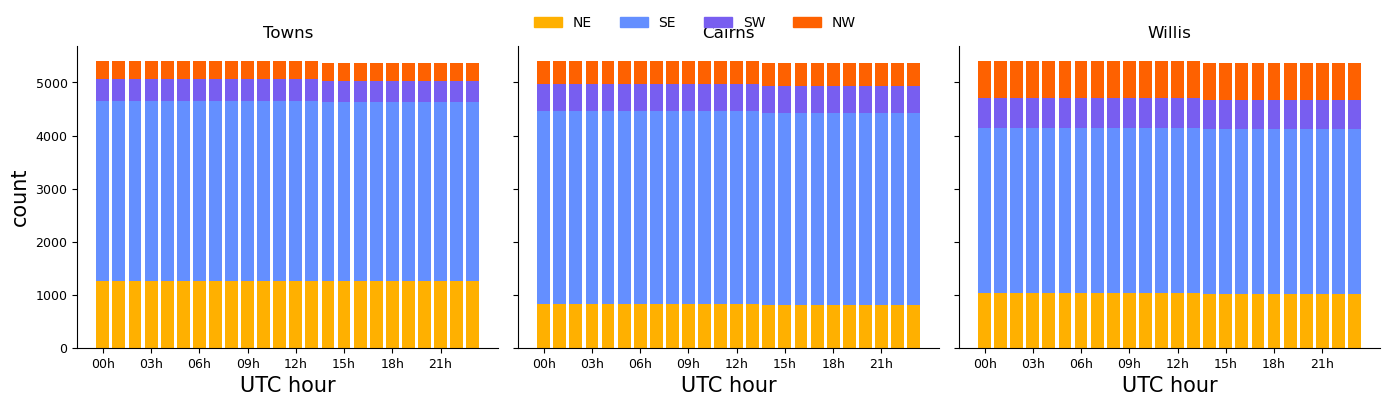

In [10]:
def hourly_counts(timestamps):
    return pd.DatetimeIndex(timestamps).hour.value_counts().reindex(range(24), fill_value=0).values

hours = np.arange(24)
locations = {
    'Towns':  {'NE': ne_towns,  'SE': se_towns,  'SW': sw_towns,  'NW': nw_towns},
    'Cairns': {'NE': ne_cairns, 'SE': se_cairns, 'SW': sw_cairns, 'NW': nw_cairns},
    'Willis': {'NE': ne_willis, 'SE': se_willis, 'SW': sw_willis, 'NW': nw_willis},
}

colors = {'NE': '#FFB000', 'SE': '#648FFF', 'SW': '#785EF0', 'NW': '#FE6100'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (loc_name, regimes) in zip(axes, locations.items()):
    bottom = np.zeros(24)
    for regime, timestamps in regimes.items():
        counts = hourly_counts(timestamps)
        ax.bar(hours, counts, bottom=bottom, label=regime,
               color=colors[regime], width=0.8, edgecolor='none')
        bottom += counts

    ax.set_title(loc_name, fontsize=12, fontweight='normal')
    ax.set_xlabel('UTC hour')
    ax.set_xticks(hours[::3])
    ax.set_xticklabels([f'{h:02d}h' for h in hours[::3]], fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)

axes[0].set_ylabel('count')

handles = [plt.Rectangle((0,0),1,1, color=colors[r]) for r in colors]
fig.legend(handles, colors.keys(), loc='upper center', ncol=4,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

In [11]:
def wind_regimes_by_hour(barra_regime_ds: xr.Dataset):    
    winds = barra_regime_ds.wind_dir.compute()
    ne = winds[(winds>=0)&(winds<=90)].time.values
    se = winds[(winds>90)&(winds<=180)].time.values
    sw = winds[(winds>180)&(winds<=270)].time.values
    nw = winds[(winds>270)&(winds<=360)].time.values
    return ne,se,sw,nw
ne_t,se_t,sw_t,nw_t = wind_regimes_by_hour(barra_towns)
ne_c,se_c,sw_c,nw_c = wind_regimes_by_hour(barra_cairns)
ne_w,se_w,sw_w,nw_w = wind_regimes_by_hour(barra_willis)

In [29]:
import dask.array as da

def regime_agreement(by_hour, by_day):
    """
    Compute 4x4 confusion matrix (rows=by_hour, cols=by_day) as percentages.
    Vectorised with dask. by_hour and by_day are dicts: {'NE': array, 'SE': array, ...}
    """
    all_times = np.unique(np.concatenate([*by_hour.values(), *by_day.values()]))

    REGIME_IDX = {'NE': 0, 'SE': 1, 'SW': 2, 'NW': 3}

    def build_label_array(regimes_dict):
        arr = np.full(len(all_times), -1, dtype=np.int8)
        for regime_name, regime_times in regimes_dict.items():
            idx = REGIME_IDX[regime_name]
            mask = np.isin(all_times, regime_times)
            arr[mask] = idx
        return da.from_array(arr, chunks='auto')

    # Pass dicts directly — no tuple indexing
    h_labels = build_label_array(by_hour)
    d_labels = build_label_array(by_day)

    valid   = (h_labels >= 0) & (d_labels >= 0)
    h_valid = h_labels[valid].compute()
    d_valid = d_labels[valid].compute()

    flat_idx = h_valid * 4 + d_valid
    mat = np.bincount(flat_idx, minlength=16).reshape(4, 4)

    row_sums = mat.sum(axis=1, keepdims=True)
    return np.where(row_sums > 0, mat / row_sums * 100, 0)


def plot_regime_correlation(locations: dict):
    fig, axes = plt.subplots(1, len(locations), figsize=(5 * len(locations) + 1, 4), sharey=True)
    regimes = ['NE', 'SE', 'SW', 'NW']
    cmap = mpl.cm.Blues

    for ax, (loc_name, (by_hour, by_day)) in zip(axes, locations.items()):
        mat = regime_agreement(by_hour, by_day)
        im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=100, aspect='auto')

        for i in range(4):
            for j in range(4):
                val = mat[i, j]
                color = 'white' if val > 60 else '#222222'
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=11, color=color, fontweight='normal')

        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(regimes)
        ax.set_yticklabels(regimes)
        ax.set_xlabel('By day (noon LST)', fontsize=12)
        ax.set_title(loc_name, fontsize=13)
        ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    axes[0].set_ylabel('By hour', fontsize=12)

    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cax, orientation='vertical')
    cbar.set_label('% of by-hour samples', fontsize=11)

    fig.suptitle('Regime classification agreement: by hour vs by day', fontsize=14, y=1.02)
    plt.show()

    # Print sample counts for each location and regime
    print(f"\n{'location':<10} {'method':<10} {'NE':>8} {'SE':>8} {'SW':>8} {'NW':>8} {'total':>8}")
    print("-" * 58)
    for loc_name, (by_hour, by_day) in locations.items():
        for method_name, regime_dict in [('by hour', by_hour), ('by day', by_day)]:
            counts = {r: len(regime_dict[r]) for r in regimes}
            total  = sum(counts.values())
            print(f"{loc_name:<10} {method_name:<10} "
                  f"{counts['NE']:>8} {counts['SE']:>8} {counts['SW']:>8} {counts['NW']:>8} {total:>8}")
        print()

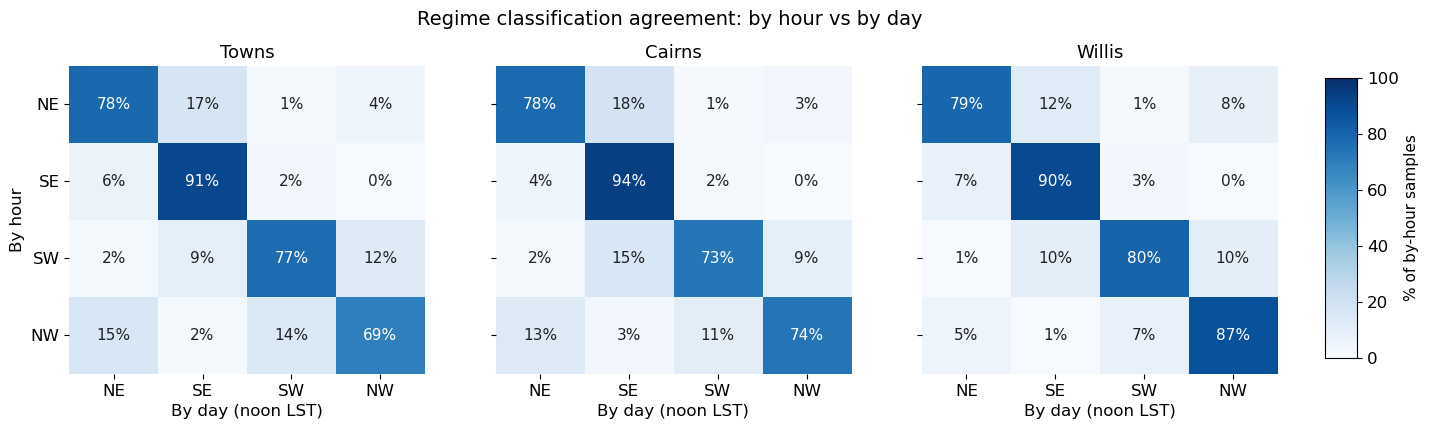

In [28]:
def shift_regime_dict(regime_dict: dict, longitude_center: float) -> dict:
    """
    Apply UTC → LST shift to all timestamp arrays in a regime dict.
    Args:
        regime_dict:      {'NE': array, 'SE': array, 'SW': array, 'NW': array}
        longitude_center: representative longitude for LST offset
    Returns:
        dict with same keys, timestamps shifted to LST
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)
    return {regime: times + offset for regime, times in regime_dict.items()}


locations = {
    'Towns': (
        shift_regime_dict({'NE': ne_t, 'SE': se_t, 'SW': sw_t, 'NW': nw_t}, lon_towns),
        shift_regime_dict({'NE': ne_towns, 'SE': se_towns, 'SW': sw_towns, 'NW': nw_towns}, lon_towns),
    ),
    'Cairns': (
        shift_regime_dict({'NE': ne_c, 'SE': se_c, 'SW': sw_c, 'NW': nw_c}, lon_cairns),
        shift_regime_dict({'NE': ne_cairns, 'SE': se_cairns, 'SW': sw_cairns, 'NW': nw_cairns}, lon_cairns),
    ),
    'Willis': (
        shift_regime_dict({'NE': ne_w, 'SE': se_w, 'SW': sw_w, 'NW': nw_w}, lon_willis),
        shift_regime_dict({'NE': ne_willis, 'SE': se_willis, 'SW': sw_willis, 'NW': nw_willis}, lon_willis),
    ),
}
plot_regime_correlation(locations)

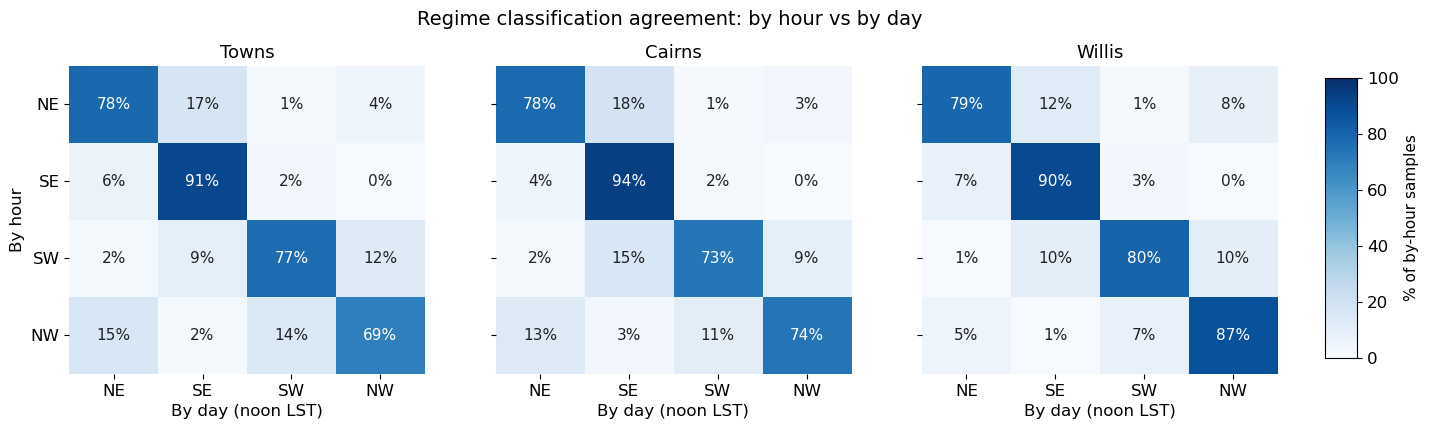


location   method           NE       SE       SW       NW    total
----------------------------------------------------------
Towns      by hour       30292    83395     8355     7822   129864
Towns      by day        30206    81304     9800     8104   129414

Cairns     by hour       18670    87242    12510    11442   129864
Cairns     by day        19652    87216    12204    10342   129414

Willis     by hour       22868    79237    12276    15483   129864
Willis     by day        24596    74714    13308    16796   129414



In [30]:
# UTC times (same results if in LST)
locations = {
    'Towns':  ({'NE': ne_t, 'SE': se_t, 'SW': sw_t, 'NW': nw_t},
               {'NE': ne_towns, 'SE': se_towns, 'SW': sw_towns, 'NW': nw_towns}),
    'Cairns': ({'NE': ne_c, 'SE': se_c, 'SW': sw_c, 'NW': nw_c},
               {'NE': ne_cairns, 'SE': se_cairns, 'SW': sw_cairns, 'NW': nw_cairns}),
    'Willis': ({'NE': ne_w, 'SE': se_w, 'SW': sw_w, 'NW': nw_w},
               {'NE': ne_willis, 'SE': se_willis, 'SW': sw_willis, 'NW': nw_willis}),
}

plot_regime_correlation(locations)

# Plot F04 EQPT

In [5]:
# open BARRA-R2 850hPa wind dataset and EQPT datasets
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_towns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_cairns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_willis.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_towns_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_towns.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_cairns_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_cairns.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_willis_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_willis.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))

In [6]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [7]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw

In [8]:
# site = {
#     'towns' : {
#         'eqpt': UTC_to_LST(barra_towns_eqpt.eqpt,'Australia/Sydney').mean('time'),
#         'eqpt25':UTC_to_LST(barra_towns_eqpt.eqpt,'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75':UTC_to_LST(barra_towns_eqpt.eqpt,'Australia/Sydney').quantile(0.75,dim='time'),
      
#         'eqptNE': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=ne_towns),'Australia/Sydney').mean('time'),
#         'eqpt25NE':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=ne_towns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75NE':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=ne_towns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nNE':len(UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=ne_towns),'Australia/Sydney').values[0]),
        
#         'eqptSE': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=se_towns),'Australia/Sydney').mean('time'),
#         'eqpt25SE':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=se_towns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75SE':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=se_towns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nSE':len(UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=se_towns),'Australia/Sydney').values[0]),
    
#         'eqptSW': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=sw_towns),'Australia/Sydney').mean('time'),
#         'eqpt25SW':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=sw_towns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75SW':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=sw_towns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nSW':len(UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=sw_towns),'Australia/Sydney').values[0]),

#         'eqptNW': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=nw_towns),'Australia/Sydney').mean('time'),
#         'eqpt25NW':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=nw_towns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75NW':UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=nw_towns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nNW':len(UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=nw_towns),'Australia/Sydney').values[0]),
#     },

#     'cairns' : {
#         'eqpt': UTC_to_LST(barra_cairns_eqpt.eqpt,'Australia/Sydney').mean('time'),
#         'eqpt25':UTC_to_LST(barra_cairns_eqpt.eqpt,'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75':UTC_to_LST(barra_cairns_eqpt.eqpt,'Australia/Sydney').quantile(0.75,dim='time'),
        
#         'eqptNE': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=ne_cairns),'Australia/Sydney').mean('time'),
#          'eqpt25NE':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=ne_cairns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75NE':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=ne_cairns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nNE':len(UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=ne_cairns),'Australia/Sydney').values[0]),
        
#         'eqptSE': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=se_cairns),'Australia/Sydney').mean('time'),
#          'eqpt25SE':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=se_cairns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75SE':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=se_cairns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nSE':len(UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=se_cairns),'Australia/Sydney').values[0]),
        
#         'eqptSW': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=sw_cairns),'Australia/Sydney').mean('time'),
#         'eqpt25SW':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=sw_cairns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75SW':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=sw_cairns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nSW':len(UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=sw_cairns),'Australia/Sydney').values[0]),
        
#         'eqptNW': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=nw_cairns),'Australia/Sydney').mean('time'),
#         'eqpt25NW':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=nw_cairns),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75NW':UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=nw_cairns),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nNW':len(UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=nw_cairns),'Australia/Sydney').values[0]),
#     },

#     'willis' : {
#         'eqpt': UTC_to_LST(barra_willis_eqpt.eqpt,'Australia/Sydney').mean('time'),
#         'eqpt25':UTC_to_LST(barra_willis_eqpt.eqpt,'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75':UTC_to_LST(barra_willis_eqpt.eqpt,'Australia/Sydney').quantile(0.75,dim='time'),
        
#         'eqptNE': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=ne_willis),'Australia/Sydney').mean('time'),
#         'eqpt25NE':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=ne_willis),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75NE':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=ne_willis),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nNE':len(UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=ne_willis),'Australia/Sydney').values[0]),
        
#         'eqptSE': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=se_willis),'Australia/Sydney').mean('time'),
#           'eqpt25SE':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=se_willis),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75SE':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=se_willis),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nSE':len(UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=se_willis),'Australia/Sydney').values[0]),
        
#         'eqptSW': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=sw_willis),'Australia/Sydney').mean('time'),
#         'eqpt25SW':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=sw_willis),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75SW':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=sw_willis),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nSW':len(UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=sw_willis),'Australia/Sydney').values[0]),
        
#         'eqptNW': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=nw_willis),'Australia/Sydney').mean('time'),
#          'eqpt25NW':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=nw_willis),'Australia/Sydney').quantile(0.25,dim='time'),
#         'eqpt75NW':UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=nw_willis),'Australia/Sydney').quantile(0.75,dim='time'),
#         'nNW':len(UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=nw_willis),'Australia/Sydney').values[0]),
#     }
# }

In [9]:
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

eqpt_data = {
    'towns':  barra_towns_eqpt,
    'cairns': barra_cairns_eqpt,
    'willis': barra_willis_eqpt,
}

# select eqpt data for each site and regime
regime_times = {
    'towns':  {'ne': ne_towns,  'se': se_towns,  'sw': sw_towns,  'nw': nw_towns},
    'cairns': {'ne': ne_cairns, 'se': se_cairns, 'sw': sw_cairns, 'nw': nw_cairns},
    'willis': {'ne': ne_willis, 'se': se_willis, 'sw': sw_willis, 'nw': nw_willis},
}

results = {
    site: {'clim': eqpt_data[site]} | {
        regime: eqpt_data[site].sel(time=times)
        for regime, times in regimes.items()
    }
    for site, regimes in regime_times.items()
}

lon_sites = {
    'towns':  lon_towns,
    'cairns': lon_cairns,
    'willis': lon_willis,
}

In [10]:
def compute_smoothed_daily_clim(da, window_days=31):
    """
    Compute a smoothed daily climatology (day-of-year × pressure).
    
    1. Group climatology by dayofyear
    2. Smooth along day-of-year axis with rolling window of 30 days to average across
    
    Returns DataArray with dims (dayofyear, pressure)
    """
    clim_raw = da.groupby('time.dayofyear').mean('time')  # (dayofyear, pressure)

    clim_smooth = clim_raw.rolling(
        dayofyear=window_days, center=True, min_periods=1
    ).mean()
    return clim_smooth

# build smoothed climatology per site
clim_smooth = {
    site: compute_smoothed_daily_clim(
        utc_to_lst_shift(results[site]['clim'].eqpt, lon_sites[site])
    )
    for site in results
}

def compute_regime_anomaly_mean(regime_da, clim_smooth_da):
    """
    Subtract smoothed daily climatology from each timestep, then take overall mean.
    
    regime_da:      (time, pressure) — raw regime-selected data
    clim_smooth_da: (dayofyear, pressure) — smoothed daily climatology
    
    Returns: (pressure,) mean anomaly
    """
    doy = regime_da.time.dt.dayofyear
    clim_matched = clim_smooth_da.sel(dayofyear=doy)  # (time, pressure)
    anomaly = regime_da - clim_matched                 # (time, pressure)
    return anomaly.mean('time')                        # (pressure,)

In [11]:
# colors
ne_c = '#00446B' # '#0072B2'
se_c = '#25B1FF' ##9DDCFF'
sw_c = '#FF9F00' #'#D55E00'
nw_c = '#7D3800' #'#F0E442'

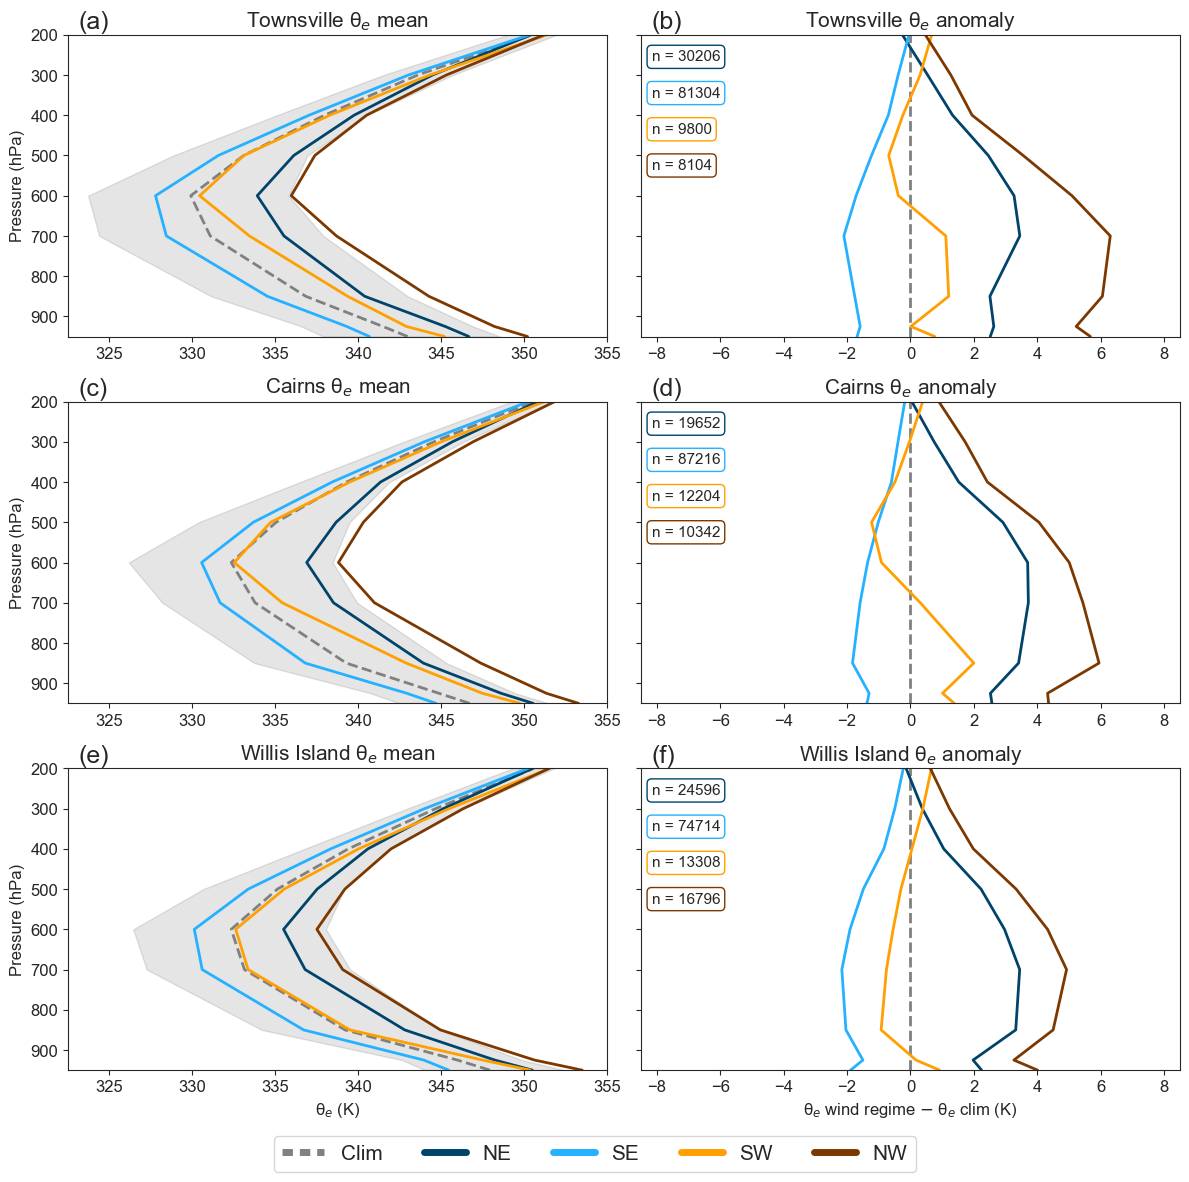

In [12]:
def plot_eqpt_profiles(results: dict, clim_smooth: dict,
                       plot_samples: bool = True,
                       clim_iqr: bool = True,
                       regime_iqr: bool = False) -> None:
    """
    Plot θₑ mean profiles and wind regime anomalies for each site.

    Layout: 3 rows (sites) × 2 cols
        col 0 (a,c,e): absolute θₑ mean profiles — clim (dashed) + 4 regimes
        col 1 (b,d,f): θₑ anomaly profiles — regime minus smoothed daily climatology

    Args:
        results:      {site: {'clim': Dataset, 'ne': Dataset, ...}}
        clim_smooth:  {site: DataArray (dayofyear, pressure)} smoothed daily climatology
        plot_samples: annotate regime sample size on anomaly panel
        clim_iqr:     shade clim IQR (25-75%) on mean panel
        regime_iqr:   shade regime IQR on mean panel
    """
    sns.set_style("ticks")

    pressure = np.array([950, 925, 850, 700, 600, 500, 400, 300, 200])

    regimes = {
        "NE": ne_c, #FFB000',
        "SE": se_c,#DC267F', #pink #'#648FFF'-light blue,
        "SW": sw_c,#785EF0',
        "NW": nw_c,#FE6100',
    }
    site_titles = {
        "towns":  "Townsville",
        "cairns": "Cairns",
        "willis": "Willis Island",
    }
    panel_labels = list(string.ascii_lowercase)

    fig, ax = plt.subplots(3, 2, figsize=(12, 12))

    for row, (location, _) in enumerate(results.items()):
        site_name = site_titles.get(location, location)
        ax_mean = ax[row, 0]   # left panel: absolute θₑ
        ax_anom = ax[row, 1]   # right panel: anomaly

        # ---- left panel: climatological mean ----
        clim_mean = results[location]["clim"].eqpt.mean('time').values

        if clim_iqr:
            # shade IQR of climatology across time
            clim_25 = results[location]["clim"].eqpt.quantile(0.25, dim='time').values
            clim_75 = results[location]["clim"].eqpt.quantile(0.75, dim='time').values
            ax_mean.fill_betweenx(pressure, clim_25, clim_75, color="black", alpha=0.1)

        mean_label = "Clim" if row == 0 else None
        ax_mean.plot(clim_mean, pressure, color="grey", linestyle='--',
                     linewidth=2, label=mean_label)

        # plot each regime mean on left panel
        for regime, color in regimes.items():
            regime_key  = regime.lower()
            regime_mean = results[location][regime_key].eqpt.mean('time').values
            ax_mean.plot(regime_mean, pressure, color=color, linewidth=2, label=None)

            if regime_iqr:
                r25 = results[location][regime_key].eqpt.quantile(0.25, dim='time').values
                r75 = results[location][regime_key].eqpt.quantile(0.75, dim='time').values
                ax_mean.fill_betweenx(pressure, r25, r75, color=color, alpha=0.1)

        # ---- right panel: anomaly = regime - smoothed daily clim ----
        ax_anom.plot([0] * len(pressure), pressure, color="grey",
                     linestyle="--", linewidth=2)  # zero reference line

        for j, (regime, color) in enumerate(regimes.items()):
            regime_key   = regime.lower()
            regime_label = regime if row == 0 else None

            # subtract smoothed daily clim per timestep, then average
            anomaly = compute_regime_anomaly_mean(
                results[location][regime_key].eqpt,
                clim_smooth[location]
            ).values

            ax_anom.plot(anomaly, pressure, color=color, linewidth=2, label=regime_label)

            # annotate sample size
            if plot_samples:
                n_val = len(results[location][regime_key].time)
                ax_anom.annotate(
                    f"n = {n_val}",
                    xy=(0.02, 0.95 - j * 0.12),
                    xycoords="axes fraction",
                    fontsize=11, ha="left", va="top",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, lw=1)
                )

        # ---- shared axis formatting ----
        for a in [ax_mean, ax_anom]:
            a.invert_yaxis()
            a.set_yticks(np.arange(200, 1000, 100))
            a.set_ylim(950, 200)

        ax_mean.set_yticklabels(["200", "300", "400", "500", "600", "700", "800", "900"])
        ax_anom.set_yticklabels([])  # shared y-axis — hide labels on right panel

        ax_mean.set_xticks(np.arange(325, 360, 5),
                           labels=["325", "330", "335", "340", "345", "350", "355"])
        ax_mean.set_xlim(322.5, 355)
        ax_anom.set_xlim(-8.5, 8.5)

        ax_mean.set_ylabel("Pressure (hPa)", fontsize=12)
        ax_mean.set_title(f"{site_name} θ$_e$ mean", fontsize=15)
        ax_anom.set_title(f"{site_name} θ$_e$ anomaly", fontsize=15)

        # panel letter labels (a,b,c,...)
        for col, a in enumerate([ax_mean, ax_anom]):
            a.text(0.02, 1.08, f'({panel_labels[row * 2 + col]})',
                   transform=a.transAxes, fontsize=18, va='top', ha='left')

    # x-axis labels on bottom row only
    ax[2, 0].set_xlabel("θ$_e$ (K)", fontsize=12)
    ax[2, 1].set_xlabel("θ$_e$ wind regime $-$ θ$_e$ clim (K)", fontsize=12)

    # shared legend below figure
    leg=fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.04),
               fontsize=15, ncol=len(regimes) + 1)
    for i, line in enumerate(leg.get_lines()):
        line.set_linewidth(5)
        if i == 0:
            line.set_dashes([1.5, 1])
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/f04v2.png',
                bbox_inches='tight', dpi=300)


plot_eqpt_profiles(results, clim_smooth)

# F05 Plot diurnal eqpt dependent on wind regime

In [12]:
# compute rolling mean climatology
def compute_smoothed_daily_clim(da, window_days=31):
    """
    Compute a smoothed daily climatology (day-of-year x pressure).
    
    1. Group climatology by dayofyear
    2. Smooth along day-of-year axis with rolling window of 30 days to average across
    
    Returns DataArray with dims (dayofyear, pressure)
    """
    clim_raw = da.groupby('time.dayofyear').mean('time')  # (dayofyear, pressure)

    clim_smooth = clim_raw.rolling(
        dayofyear=window_days, center=True, min_periods=1
    ).mean()
    return clim_smooth

def regime_anomaly(regime_da, clim_smooth_da):
    """
    Subtract smoothed seasonal clim from each timestep before hourly averaging.
    regime_da:      (time, pressure) — raw regime-selected data
    clim_smooth_da: (dayofyear, pressure) — smoothed daily climatology
    """
    doy = regime_da.time.dt.dayofyear
    clim_matched = clim_smooth_da.sel(dayofyear=doy)  # match clim to each timestep
    anomaly = regime_da - clim_matched                 # subtract before averaging
    return anomaly.groupby('time.hour').mean('time') 

In [13]:
# define dictionaries for hourly mean eqpt
ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

eqpt_data = {
    'towns':  barra_towns_eqpt,
    'cairns': barra_cairns_eqpt,
    'willis': barra_willis_eqpt,
}

# select eqpt data for each site and regime
regime_times = {
    'towns':  {'ne': ne_towns,  'se': se_towns,  'sw': sw_towns,  'nw': nw_towns},
    'cairns': {'ne': ne_cairns, 'se': se_cairns, 'sw': sw_cairns, 'nw': nw_cairns},
    'willis': {'ne': ne_willis, 'se': se_willis, 'sw': sw_willis, 'nw': nw_willis},
}

results = {
    site: {'clim': eqpt_data[site]} | {
        regime: eqpt_data[site].sel(time=times)
        for regime, times in regimes.items()
    }
    for site, regimes in regime_times.items()
}
lon_sites = {
    'towns':  lon_towns,
    'cairns': lon_cairns,
    'willis': lon_willis,
}

# build smoothed climatology per site
clim_smooth = {
    site: compute_smoothed_daily_clim(
        utc_to_lst_shift(results[site]['clim'], lon_sites[site])
    )
    for site in results
}

# now use clim to calc anomaly
results_hourly = {
    site: {
        'clim': utc_to_lst_shift(results[site]['clim'], lon_sites[site])
                    .groupby('time.hour').mean('time'),  # absolute clim stays as-is
        **{
            regime: regime_anomaly(
                utc_to_lst_shift(results[site][regime], lon_sites[site]),
                clim_smooth[site] # already converted to LST
            )
            for regime in ['ne', 'se', 'sw', 'nw']
        }
    }
    for site in results
}

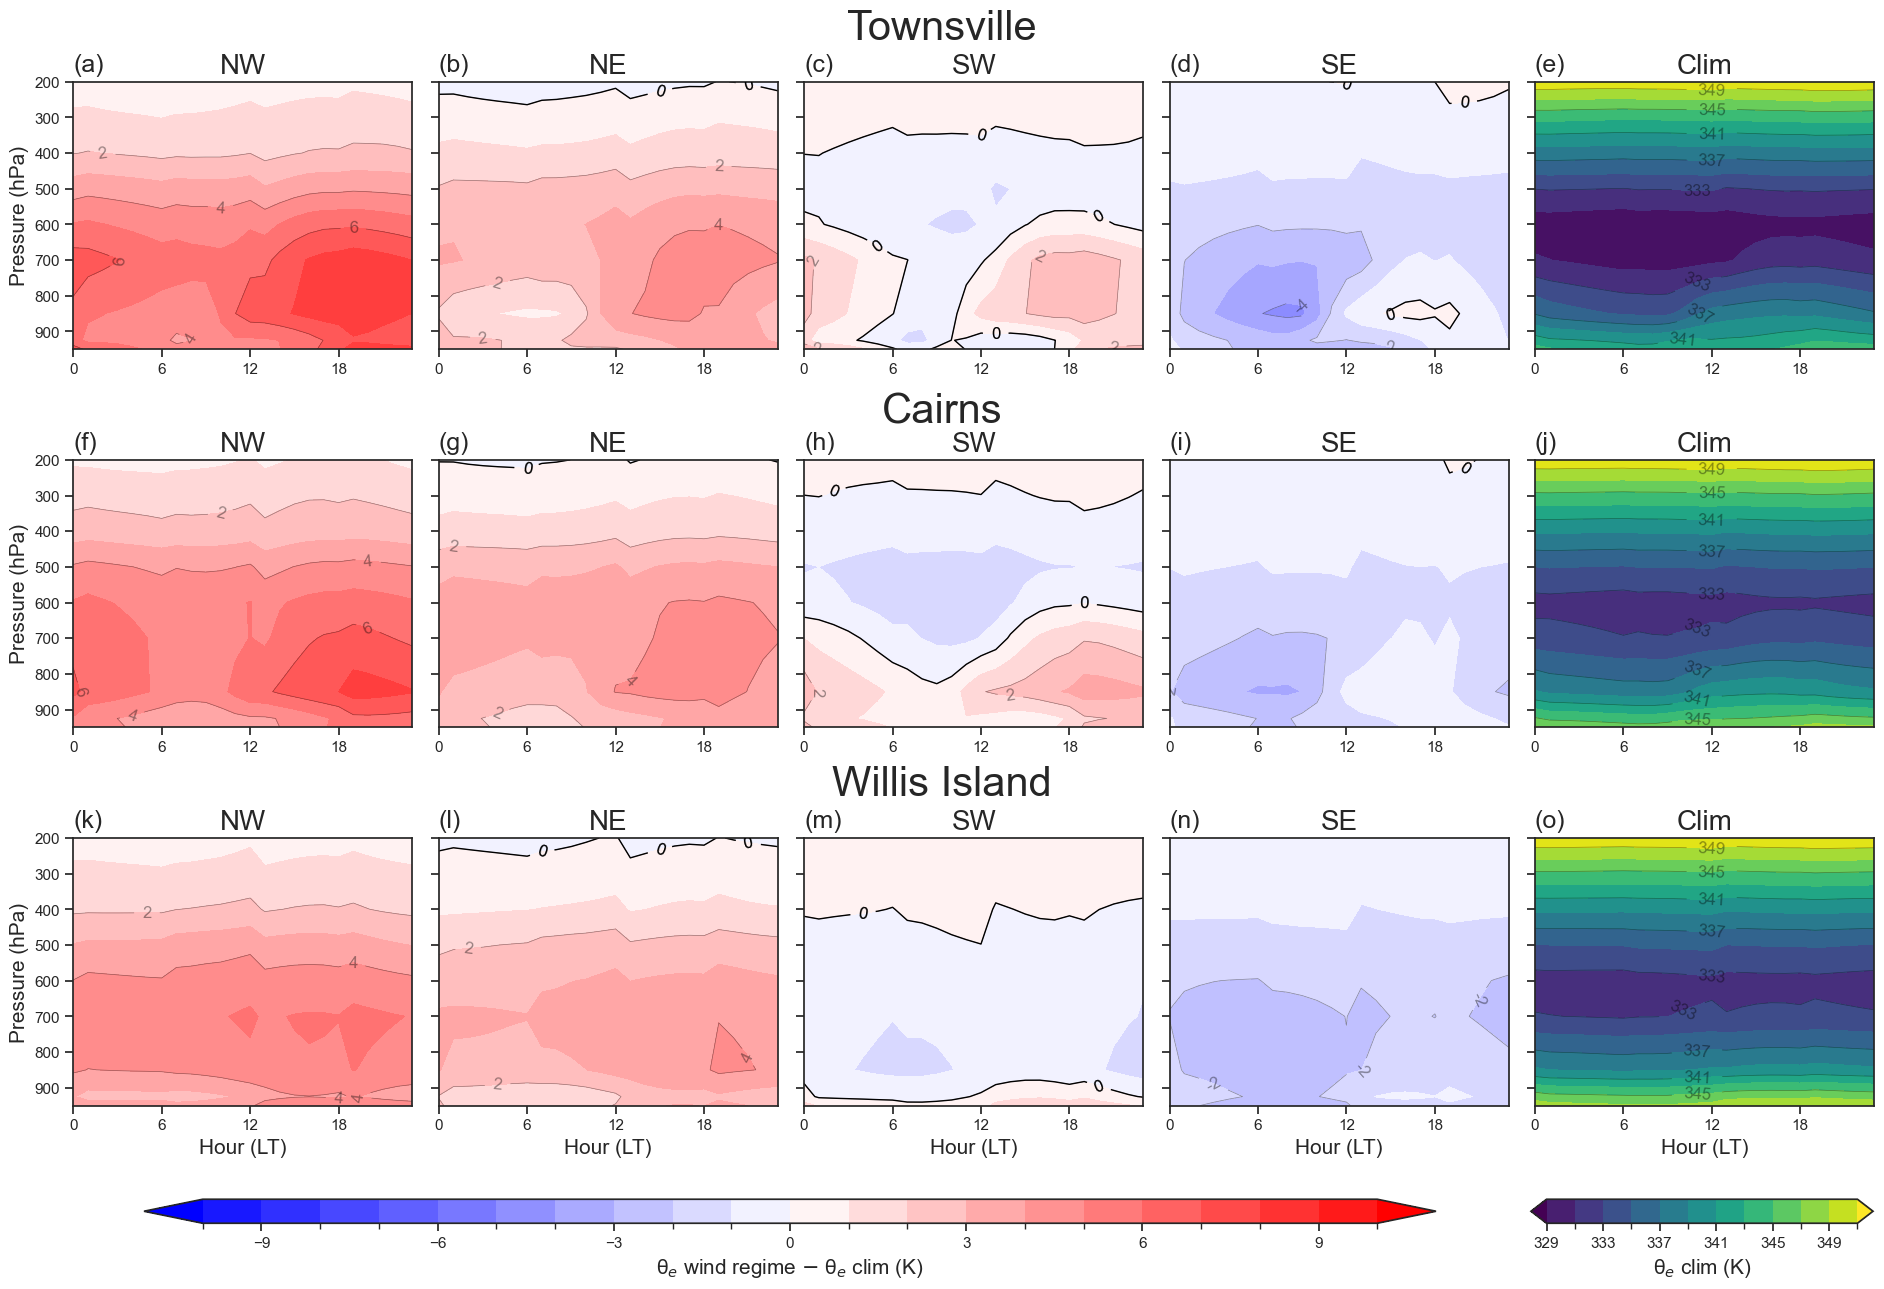

In [17]:
# plot fig5
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(19, 12))
sns.set_theme(style="ticks")

pressure = np.array([95000, 92500, 85000, 70000, 60000, 50000, 40000, 30000, 20000])
levels_diff = [-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10]
levels_abs  = [329,331,333,335,337,339,341,343,345,347,349,351]
cmap_diff   = "bwr"
cmap_abs    = "viridis"#"RdYlBu_r"

hours        = np.arange(0, 24, 1)
xticks       = np.arange(0, 24, 6)
yticks       = np.arange(20000, 100000, 10000)
yticklabels  = ["200", "300", "400", "500", "600", "700", "800", "900"]
site_labels  = ['Townsville', 'Cairns', 'Willis Island']
labels       = list(string.ascii_lowercase)

for row_idx, (site_name, regime_dict) in enumerate(results_hourly.items()):
    ax_row      = axs[row_idx]
    label_start = [0, 5, 10][row_idx]  # 5 panels per row now

    # --- cols 0-3: regime anomalies ---
    for i, (regime, title) in enumerate(zip(["nw", "ne", "sw", "se"], ["NW", "NE", "SW", "SE"])):
        # da = regime_dict[regime].eqpt - regime_dict['clim'].eqpt
        da = regime_dict[regime].eqpt
        cs_diff = ax_row[i].contourf(hours, pressure, da.T, levels=levels_diff, cmap=cmap_diff)
        c  = ax_row[i].contour(hours, pressure, da.T,
                               levels=levels_diff[::2], colors='black',
                               linestyles='-', linewidths=0.5, alpha=0.4)
        c0 = ax_row[i].contour(hours, pressure, da.T,
                               levels=[0], colors='black', linestyles='-', linewidths=1)
        ax_row[i].clabel(c,  inline=True, fontsize=12, fmt='%.0f')
        ax_row[i].clabel(c0, inline=True, fontsize=12, fmt='%.0f')
        ax_row[i].set_title(title, fontsize=20)
        ax_row[i].set_xlabel("Hour (LT)", fontsize=15)
        ax_row[i].text(0.00, 1.02, f'({labels[label_start + i]})',
                       transform=ax_row[i].transAxes, fontsize=18, va='bottom', ha='left')

    # --- col 4: absolute clim ---
    da_abs = regime_dict['clim'].eqpt
    cs_abs = ax_row[4].contourf(hours, pressure, da_abs.T, levels=levels_abs, cmap=cmap_abs)
    c_abs  = ax_row[4].contour(hours, pressure, da_abs.T,
                               levels=levels_abs[::2], colors='black',
                               linestyles='-', linewidths=0.5, alpha=0.4)
    ax_row[4].clabel(c_abs, inline=True, fontsize=12, fmt='%.0f')
    ax_row[4].set_title("Clim", fontsize=20)
    ax_row[4].set_xlabel("Hour (LT)", fontsize=15)
    ax_row[4].text(0.00, 1.02, f'({labels[label_start + 4]})',
                   transform=ax_row[4].transAxes, fontsize=18, va='bottom', ha='left')

    # --- shared formatting ---
    for j, ax in enumerate(ax_row):
        ax.invert_yaxis()
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels if j == 0 else [])
        if row_idx < len(results_hourly) - 1:
            ax.set_xlabel("")

    ax_row[0].set_ylabel("Pressure (hPa)", fontsize=15)

plt.tight_layout(h_pad=3.3, rect=[0, 0.05, 1, 1])
plt.draw()

# site labels
y_positions = [0.99, 0.67, 0.36]
for site_name, y in zip(site_labels, y_positions):
    fig.text(0.5, y, site_name, ha="center", va="bottom",fontsize=30)

# colorbar — anomaly (below cols 0-3)
cbar_ax_diff = fig.add_axes([0.08, 0.01, 0.68, 0.02])
norm_diff = mpl.colors.BoundaryNorm(levels_diff, mpl.cm.bwr.N, extend='both')
fig.colorbar(mpl.cm.ScalarMappable(norm=norm_diff, cmap=cmap_diff),
             cax=cbar_ax_diff, orientation='horizontal',
             label='θ$_e$ regime − θ$_e$ clim (K)').set_label(
             'θ$_e$ wind regime $-$ θ$_e$ clim (K)', fontsize=15)

# colorbar — absolute (below col 4)
cbar_ax_abs = fig.add_axes([0.81, 0.01, 0.18, 0.02])
norm_abs = mpl.colors.BoundaryNorm(levels_abs, mpl.cm.viridis.N, extend='both')
fig.colorbar(mpl.cm.ScalarMappable(norm=norm_abs, cmap=cmap_abs),
             cax=cbar_ax_abs, orientation='horizontal',
             label='θ$_e$ clim (K)').set_label('θ$_e$ clim (K)', fontsize=15)

plt.show()

fig.savefig('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/f05v7_12LST_windregimes-rollingclim31days.png',
            bbox_inches='tight', dpi=300)

# Preprint F05 1979-2023 climatology

In [7]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_towns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_cairns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_willis.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_towns_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_towns.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_cairns_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_cairns.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_willis_eqpt = xr.open_dataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_eqpt-ds_willis.nc').sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))

In [7]:
def UTC_to_LST(ds, timezone): # longitude
    ds = ds.copy()
    # Convert to pandas datetime in UTC
    time_objects_utc = pd.to_datetime(ds['time'].values).tz_localize('UTC')
    
    # Convert to local standard time using pytz
    local_timezone = pytz.timezone(timezone)
    time_objects_local = time_objects_utc.tz_convert(local_timezone).tz_localize(None)

    ds['time'] = time_objects_local#.tz_localize(None)
    return ds

In [9]:
def wind_times(barra_regime_ds: xr.Dataset):    
    winds = barra_regime_ds.wind_dir.compute()
    ne = winds[(winds>=0)&(winds<=90)].time.values
    se = winds[(winds>90)&(winds<=180)].time.values
    sw = winds[(winds>180)&(winds<=270)].time.values
    nw = winds[(winds>270)&(winds<=360)].time.values
    return ne,se,sw,nw
ne_towns,se_towns,sw_towns,nw_towns = wind_times(barra_towns)
ne_cairns,se_cairns,sw_cairns,nw_cairns = wind_times(barra_cairns)
ne_willis,se_willis,sw_willis,nw_willis = wind_times(barra_willis)

In [14]:
print(len(ne_willis),len(se_willis),len(sw_willis),len(nw_willis))

22868 79237 12276 15483


In [16]:
def plot_hourly_eqpt_on_axes(ax, eqpt_dict, pressure, levels):
    """Plot θₑ hourly regime panels on a given list of axes."""
    titles = ["NW", "NE", "SW", "SE"]
    cmap = "viridis"
    hours = np.arange(0, 24, 1)
    xticks = np.arange(0, 24, 6)
    yticks = np.arange(200, 1000, 100)
    yticklabels = ["200", "300", "400", "500", "600", "700", "800", "900"]

    for i, key in enumerate(["eqptNW", "eqptNE", "eqptSW", "eqptSE"]):
        cs = ax[i].contourf(hours, pressure, eqpt_dict[key], levels=levels, cmap=cmap)
        ax[i].invert_yaxis()
        ax[i].set_xticks(xticks)
        ax[i].set_yticks(yticks)
        ax[i].set_yticklabels(yticklabels)
        ax[i].set_title(titles[i],fontsize=20)
        ax[i].set_xlabel("Hour (LT)",fontsize=15)
    return cs  # for colorbar

In [17]:
sites = {
    "Townsville": {
        'eqpt': np.roll(np.load('/home/563/ac9768/GBR/barra-2/eqpt/eqpt_towns.npy'),shift=1,axis=0),
        'eqptNE': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=ne_towns),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptSE': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=se_towns),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptSW': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=sw_towns),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptNW': UTC_to_LST(barra_towns_eqpt.eqpt.sel(time=nw_towns),'Australia/Sydney').groupby('time.hour').mean('time')
    },
    "Cairns": {
        'eqpt': np.roll(np.load('/home/563/ac9768/GBR/barra-2/eqpt/eqpt_cairns.npy'),shift=1,axis=0),
        'eqptNE': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=ne_cairns),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptSE': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=se_cairns),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptSW': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=sw_cairns),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptNW': UTC_to_LST(barra_cairns_eqpt.eqpt.sel(time=nw_cairns),'Australia/Sydney').groupby('time.hour').mean('time')
    },
    "Willis Island": {
        'eqpt': np.roll(np.load('/home/563/ac9768/GBR/barra-2/eqpt/eqpt_willis.npy'),shift=1,axis=0),
        'eqptNE': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=ne_willis),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptSE': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=se_willis),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptSW': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=sw_willis),'Australia/Sydney').groupby('time.hour').mean('time'),
        'eqptNW': UTC_to_LST(barra_willis_eqpt.eqpt.sel(time=nw_willis),'Australia/Sydney').groupby('time.hour').mean('time')
    }
}

FileNotFoundError: [Errno 2] No such file or directory: '/home/563/ac9768/GBR/barra-2/eqpt/eqpt_towns.npy'

In [18]:
sites["Cairns"]["eqptNE"].sel(pressure=850)
([341.06862193, 340.60598308, 340.02459096, 339.71996787,
       339.52353101, 339.31916546, 339.23948676, 338.86101475,
       338.72659216, 338.65265408, 338.88586131, 339.72720754,
       340.99516846, 341.61387355, 341.91260901, 342.26398986,
       342.42551303, 342.4886772 , 342.4903668 , 342.4908186 ,
       342.66712837, 342.32244053, 341.94078021, 341.54790317])

([343.91982836, 343.7928892 , 343.46418276, 343.3555917 ,
       343.16973303, 342.99493828, 342.88118122, 342.70005596,
       342.77287095, 342.71362731, 342.84995599, 343.30975397,
       344.06955275, 344.46324778, 344.39691695, 344.58625197,
       344.7984931 , 344.87123875, 344.80159547, 344.61444555,
       344.95461258, 344.79514361, 344.52075901, 344.14130787])

NameError: name 'sites' is not defined

/jobfs/143243899.gadi-pbs/ipykernel_3688390/3078293868.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=1.9,rect=[0, 0, 0.9, 1])


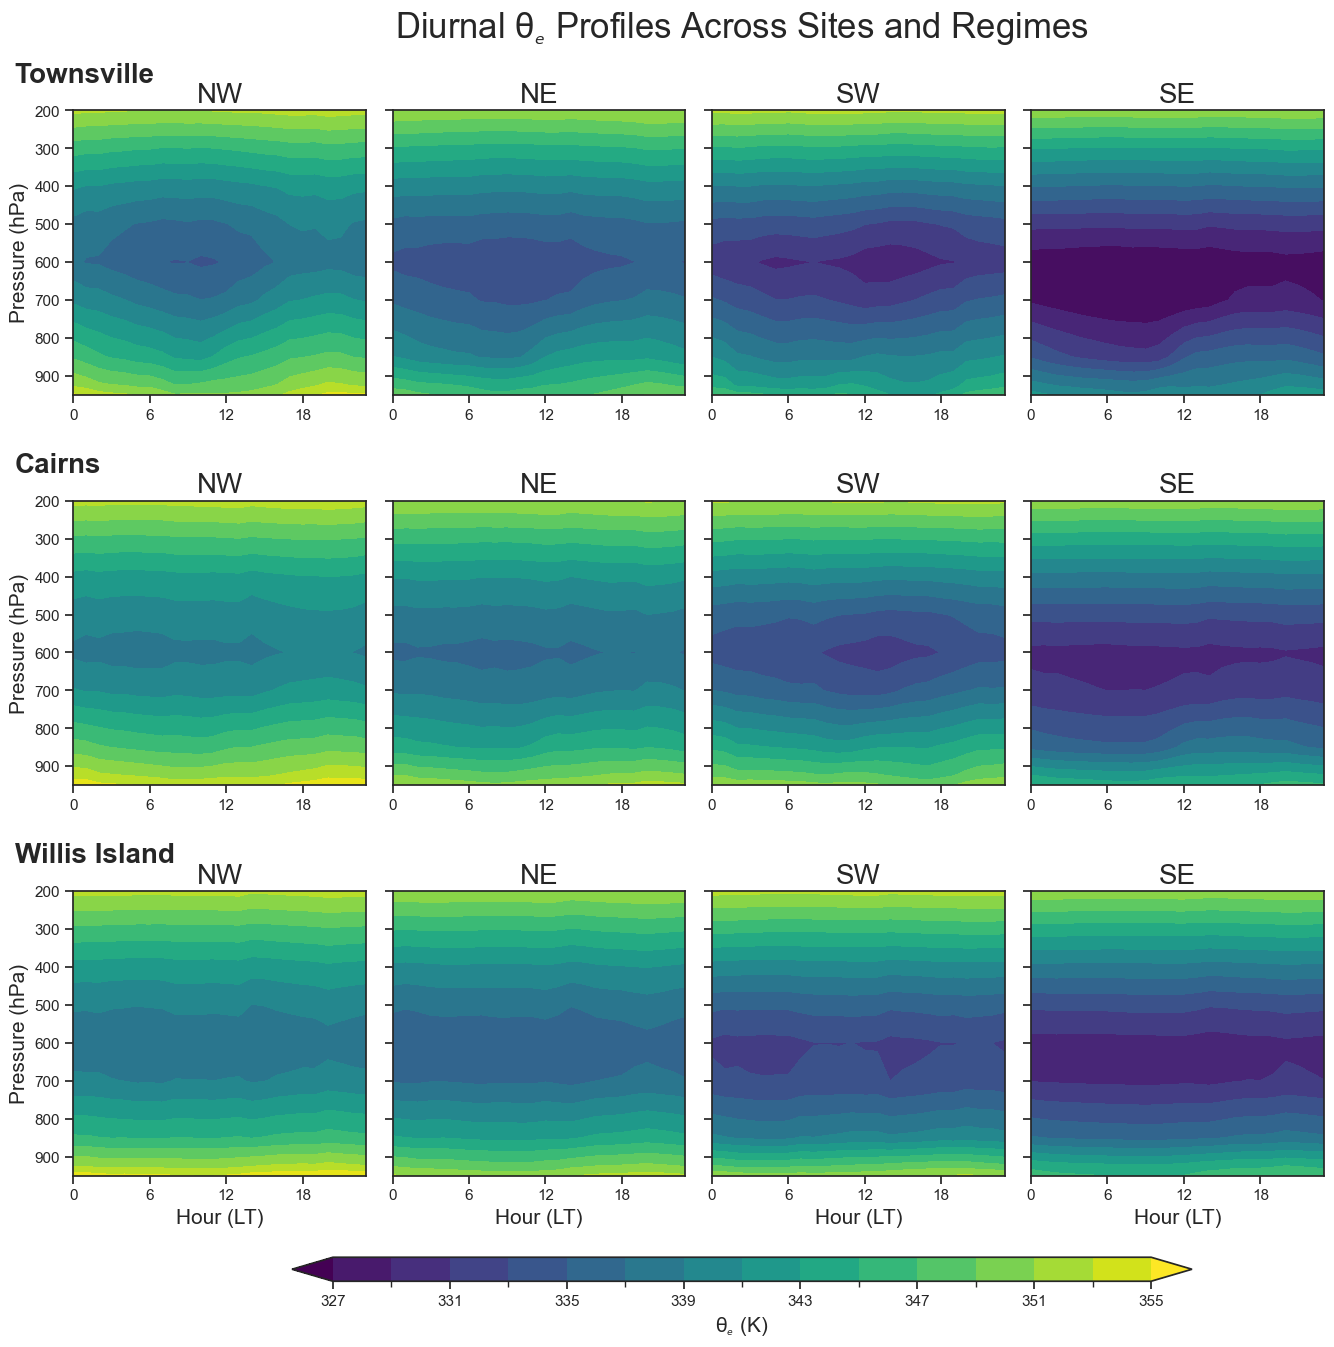

In [123]:
pressure = barra_towns_eqpt.pressure.values
levels = np.arange(327, 360, 2)
levels = [327,329,331,333,335,337,339,341,343,345,347,349,351,353,355]

# Create figure with 3×4 subplots (for 3 sites × 4 regimes each)
# sns.set_style("darkgrid")
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
sns.set_theme(style="ticks")

# Plot each site into a row of 4 subplots
for row_idx, (site_name, eqpt_dict) in enumerate(sites.items()):
    ax_row = axs[row_idx]  # Get 4 axes for this site
    plot_hourly_eqpt_on_axes(ax_row, eqpt_dict, pressure, levels)
    ax_row[0].text(-0.2, 1.1, site_name, transform=ax_row[0].transAxes,
                   fontsize=20, fontweight='bold')
    ax_row[0].set_ylabel("Pressure (hPa)",fontsize=15)
    ax_row[1].set_yticklabels([])
    ax_row[2].set_yticklabels([])
    ax_row[3].set_yticklabels([])

    # Only show x-labels for bottom row
    if row_idx < len(sites) - 1:
        for ax in ax_row:
            ax.set_xlabel("")           # Remove x-label

# Shared colorbar
cbar_ax = fig.add_axes([0.2, -0.03, 0.6, 0.02])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap="viridis")
cmap = mpl.cm.viridis
norm = mpl.colors.BoundaryNorm(levels, cmap.N, extend='both')
sm.set_array(levels)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm,cmap=cmap), cax=cbar_ax,orientation='horizontal')
cbar.set_label(label='θ$_{\u2091}$ (K)',fontsize=15)
plt.tight_layout(h_pad=1.9,rect=[0, 0, 0.9, 1])
plt.suptitle("Diurnal θ$_{\u2091}$ Profiles Across Sites and Regimes", fontsize=25, y=1.03)
plt.show()
fig.savefig('/home/563/ac9768/GBR/plots/eqpt_diurnal_cycle-1979_2023.png', bbox_inches='tight', dpi=400)